# 🤖 K-Nearest Neighbors Classifier
---

## 🎯 Objectives

After completing this, I will be able to:

- 📊 Use **K-Nearest Neighbors (KNN)** to classify data  
- 🧠 Apply a **KNN classifier** on a real-world dataset  
- 🔍 Understand how similarity between data points drives predictions  

---

## 🚀 Overview

Here, I’ll walk through a practical example of using the **K-Nearest Neighbors algorithm**.

What I’ll be doing:

- 📥 Loading a **customer dataset**
- 🧹 Preparing and fitting the data
- 🤖 Applying the **KNN algorithm**
- 🎯 Predicting the class of a new data point

This hands-on approach helps me better understand how KNN works in real-world scenarios and how distance-based classification can be used effectively.

---

Let’s get started! 💪✨

In [4]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
%matplotlib inline

## 📖 Problem Context

Imagine I’m working with a telecommunications provider that has segmented its customers into **four groups** based on their service usage patterns 📡.

If I can use **demographic data** to predict which group a customer belongs to, the company can create **personalized offers** for future customers 🎯.

This is a classic **classification problem**:
> Given a dataset with predefined labels, I need to build a model that can predict the class of a new or unknown case.

---

## 🧩 Features & Target

In this example, I’ll use demographic features such as:

- 🌍 Region  
- 🎂 Age  
- 💍 Marital status  

The target variable is **`custcat`**, which represents the customer category.

It has four possible values:

- 📦 **Basic Service**  
- 💻 **E-Service**  
- ➕ **Plus Service**  
- 🌐 **Total Service**

---

## 🎯 Objective

My goal is to build a **classifier** that can predict the correct service category for new customers.

To achieve this, I’ll use a simple yet powerful algorithm:
👉 **K-Nearest Neighbors (KNN)**

---

## 📥 Load Data

Let’s start by loading the dataset using **pandas** and displaying the first few rows 👇

In [5]:
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/teleCust1000t.csv')
df.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,reside,custcat
0,2,13,44,1,9,64.0,4,5,0.0,0,2,1
1,3,11,33,1,7,136.0,5,5,0.0,0,6,4
2,3,68,52,1,24,116.0,1,29,0.0,1,2,3
3,2,33,33,0,12,33.0,2,0,0.0,1,1,1
4,2,23,30,1,9,30.0,1,2,0.0,0,4,3


## 📊 Data Visualization and Analysis

Before building the model, I want to better understand the dataset 🔍

A good starting point is to look at how the data is distributed across the different classes.

---

## 📈 Class Distribution

Let’s explore the **class-wise distribution** of the dataset to see how many customers fall into each category.

This helps me:

- ⚖️ Check if the dataset is balanced or imbalanced  
- 🧠 Understand how frequent each service category is  
- 📉 Anticipate potential bias in the model  

Now, let’s visualize or count the number of instances in each class 👇

In [6]:
df['custcat'].value_counts()

custcat
3    281
1    266
4    236
2    217
Name: count, dtype: int64

From the distribution, I can observe the following:

- ➕ **281 customers** opted for *Plus Service*  
- 📦 **266 customers** opted for *Basic Service*  
- 🌐 **236 customers** opted for *Total Service*  
- 💻 **217 customers** opted for *E-Service*  

---

## ⚖️ Conclusion

The dataset appears to be **fairly balanced** across all classes ✅

This means:

- 🚫 No class is significantly overrepresented  
- 🎯 The model is less likely to be biased toward a specific category  
- 👍 No need for special techniques (like resampling) to handle class imbalance  

This is a good starting point for building a reliable classifier 🚀
## 🔗 Feature Correlation

To better understand the relationships within the dataset, I can visualize a **correlation map (heatmap)** 🧠

This helps me see how different features are related to each other.

---

## 📌 Why It Matters

Analyzing correlations allows me to:

- 🔍 Identify strong relationships between variables  
- ⚠️ Detect multicollinearity (highly correlated features)  
- 🧹 Decide if some features might be redundant  
- 📈 Gain deeper insights into the structure of the data  

---

## 📊 Next Step

Let’s generate a **correlation heatmap** to visualize these relationships 👇

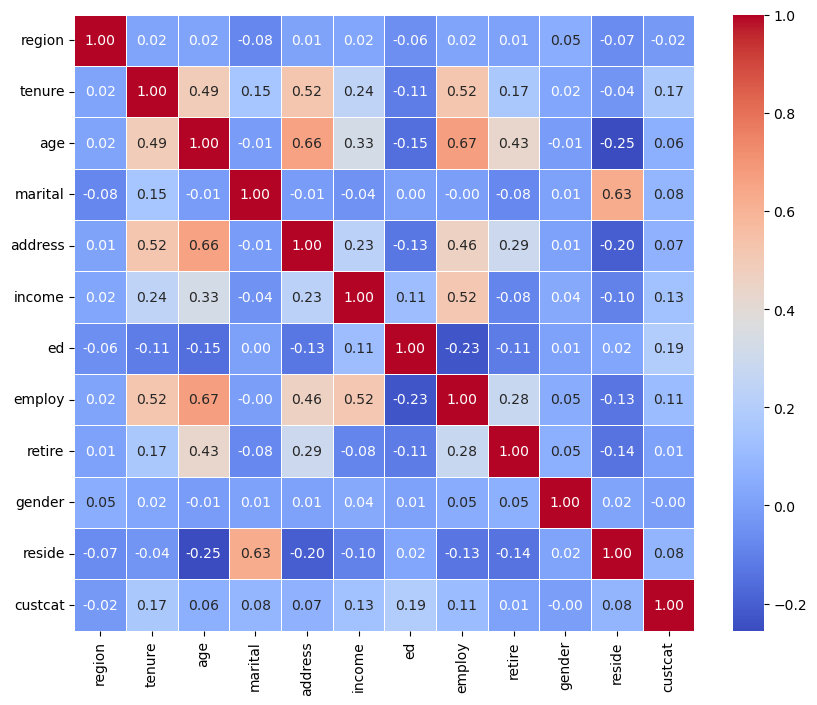

In [14]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.show()

From the correlation map, I can see that some features are more strongly related than others 🔍  
This essentially reflects the **strength of the relationship** between pairs of variables.

---

## 🎯 Focus on the Target Variable

What really matters here is how each feature correlates with the target variable 👉 **`custcat`**

By analyzing this, I can:

- 🧠 Identify the most important features for prediction  
- 🎯 Focus on variables that have stronger influence on the target  
- 🧹 Potentially ignore less relevant features to simplify the model  

---

## 📊 Feature Importance via Correlation

To make this analysis clearer, I can compute the correlation of each feature with **`custcat`** and sort them by their **absolute values**.

This will give me a ranked list of features from most to least relevant 📈

---

## 💻 Next Step

The following code snippet returns the features sorted in descending order based on their correlation with the target variable 👇

In [15]:
correlaction_values = abs(df.corr()['custcat'].drop('custcat')).sort_values(ascending=False)
print(correlaction_values)

ed         0.193864
tenure     0.166691
income     0.134525
employ     0.110011
marital    0.083836
reside     0.082022
address    0.067913
age        0.056909
region     0.023771
retire     0.008908
gender     0.004966
Name: custcat, dtype: float64


From the correlation analysis, I can conclude that:

- 📉 **`retire`** and **`gender`** have the *least influence* on the target variable **`custcat`**  
- 📈 **`ed` (education)** and **`tenure`** have the *strongest impact* on predicting customer category  

This gives me a clearer idea of which features are more important for the model 🧠

---

## 🔀 Separate Input and Target Features

Now that I understand the feature importance, the next step is to split the dataset into:

- 🧾 **Input features (X)** → all independent variables  
- 🎯 **Target variable (y)** → the column **`custcat`**

This separation is essential before training any machine learning model.

---

## 💻 Next Step

Let’s define **X** and **y** to prepare the data for training 👇

In [16]:
X = df.drop('custcat', axis=1)
y = df['custcat']

## ⚖️ Normalize Data

Data normalization is a crucial step when working with **K-Nearest Neighbors (KNN)** 🤖

---

## 🧠 Why Normalization Matters

KNN makes predictions based on the **distance between data points** 📏

For a given test point, the algorithm:

- 🔍 Computes the distance to all other data points  
- 🤝 Identifies the **k-nearest neighbors**  
- 🎯 Assigns a class based on those neighbors  

---

## ⚠️ The Problem Without Normalization

If features are on different scales:

- 📊 Variables with larger values can dominate the distance calculation  
- ❌ This can lead to misleading results  
- 🧩 The model may focus on magnitude instead of real relationships  

---

## ✅ The Solution: Standardization

By normalizing (standardizing) the data:

- 📉 Each feature has a **mean of 0**  
- 📈 Each feature has a **standard deviation of 1**  
- ⚖️ All features contribute equally to distance calculations  

---

## 🚀 Why This Improves KNN

- 🧠 Better representation of actual feature relationships  
- 🎯 More accurate neighbor selection  
- 📊 Improved overall model performance  

---

## 💻 Next Step

Let’s normalize the dataset before applying the KNN model 👇

In [19]:
X_norm = StandardScaler().fit_transform(X)

## 🔀 Train-Test Split

Now, I’ll split the dataset into **training** and **testing** sets 🧠

---

## 🎯 Why This Step Is Important

- 🏋️ The **training set** is used to train the model  
- 🧪 The **testing set** is used to evaluate its performance on unseen data  
- 📊 This helps me check how well the model generalizes  

---

## ⚖️ Splitting Strategy

I’ll use:

- 📦 **80% of the data** for training  
- 🧪 **20% of the data** for testing  

---

## 🔁 Reproducibility

By setting a **random state**, I ensure that:

- 🔄 The split remains the same across multiple runs  
- 📊 Results are consistent and reproducible  

---

## 💻 Next Step

Let’s perform the train-test split using the appropriate function 👇

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=4)

## 🤖 KNN Classification

With the data prepared, I’m ready to **train the K-Nearest Neighbors (KNN) model** 🚀

---

## 🏋️ Training the Model

I’ll start by choosing a **small value of k**, for example:

- 🔢 `k = 4`  

This means that for each test point, the algorithm will look at the **4 nearest neighbors** in the training data to predict its class.

---

## 📌 Why Start Small?

- A small `k` allows the model to **capture local patterns** in the data  
- Too small a value may make the model sensitive to noise  
- Later, I can experiment with different `k` values to **optimize performance**

---

## 💻 Next Step

Let’s fit the **KNN classifier** on the training data and see how it performs 👇

In [35]:
k = 3
#Train Model and Predict  
knn_classifier_3 = KNeighborsClassifier(n_neighbors=k)
knn_model_3 = knn_classifier_3.fit(X_train,y_train)

## 🧩 Predicting with KNN

Now that the **KNN model is trained**, I can use it to **make predictions** on the test set 🎯

---

## 🔍 What Happens Here

- The model looks at each test data point  
- 🔢 Computes distances to all training points  
- 🤝 Identifies the **k-nearest neighbors**  
- 🏷️ Assigns the class that is most common among those neighbors  

---

## 💻 Next Step

Let’s generate predictions for the test dataset and see how well the model performs 👇

In [32]:
yhat4 = knn_model.predict(X_test)

## 📊 Accuracy Evaluation

After making predictions, it’s important to **measure how well the model is performing** ✅

---

## 🧠 Understanding Accuracy in Multiclass Classification

For multiclass problems like this:

- The **accuracy score** measures how many predictions **exactly match** the true labels  
- It’s essentially the same as computing a **subset accuracy** or **Jaccard score**  
- The score ranges from **0 to 1**, where **1** means perfect prediction  

---

## 🔍 Why It Matters

- 🎯 Shows how closely the predicted labels match the actual labels  
- 📊 Helps evaluate whether the model is **reliable**  
- 🛠️ Guides me in choosing the **best value of k** and other parameters  

---

## 💻 Next Step

Let’s calculate the **accuracy score** for the test dataset to evaluate the KNN model 👇

In [37]:
print("Test set Accuracy: ", accuracy_score(y_test, yhat4))

Test set Accuracy:  0.31


## 🔁 Rebuilding the KNN Model with k = 6

To see how different choices of **k** affect the model’s performance, I’ll **retrain the KNN classifier** with:

- 🔢 `k = 6`  

This means the algorithm will now consider the **6 nearest neighbors** when predicting the class of a test point.

---

## 🏋️ Training the Model

1. Initialize the KNN classifier with `k = 6`  
2. Fit it to the **training data**  
3. Use it to **predict the test set**  

---

## 💻 Next Step

After retraining, I’ll generate predictions for the test set and **compare the accuracy** with the previous model (`k = 4`) 👇

In [38]:
k = 6
#Train Model and Predict  
knn_classifier_6 = KNeighborsClassifier(n_neighbors=k)
knn_model_6 = knn_classifier_6.fit(X_train,y_train)
yhat6 = knn_model_6.predict(X_test)
print("Test set Accuracy: ", accuracy_score(y_test, yhat6))

Test set Accuracy:  0.31


## 🎯 Choosing the Correct Value of k

In K-Nearest Neighbors, **`k`** represents the number of nearest neighbors considered when making predictions 🔢  

---

## ⚠️ Why k Matters

- A small `k` can make the model **sensitive to noise**  
- A large `k` may **smooth over local patterns**, losing detail  
- The choice of `k` directly affects the **accuracy** of the model  

---

## 🛠️ How to Choose k

The common approach is:

1. Train the KNN model on the **training set** for a range of `k` values  
2. Evaluate **accuracy** on the **testing set**  
3. Compare results to find the **optimal k** (the one with the highest accuracy)  

---

## 📊 Practical Example

I will check the model performance for **10 values of k**, from **1 to 9**, and compute:

- ✅ **Accuracy** for each k  
- 📉 **Standard deviation of accuracy** to understand variability  

This gives a **holistic picture** of how the model behaves with different k values and helps select the **best-performing k**.  

---

## 💻 Next Step

Let’s iterate through different k values, record the accuracies, and visualize the results 👇

In [39]:
Ks = 10
acc = np.zeros((Ks))
std_acc = np.zeros((Ks))
for n in range(1,Ks+1):
    #Train Model and Predict  
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat = knn_model_n.predict(X_test)
    acc[n-1] = accuracy_score(y_test, yhat)
    std_acc[n-1] = np.std(yhat==y_test)/np.sqrt(yhat.shape[0])

## 📈 Plotting Model Accuracy for Different k Values

To visualize how the choice of **k** affects model performance, I can **plot the accuracy** for each value of k 🔢

---

## 🎯 What This Shows

- ✅ **Mean accuracy** for each k  
- 📉 **Standard deviation** to see variability and reliability  
- 🎯 Helps identify the **most suitable k** for the dataset  

---

## 🔍 Why This Helps

- Makes it easy to **spot the k with the highest performance**  
- Visualizes **how sensitive the model is to different k values**  
- Guides me in selecting the **optimal number of neighbors** for KNN  

---

## 💻 Next Step

Let’s generate a plot of **accuracy vs. k** with **error bars** representing standard deviation 👇

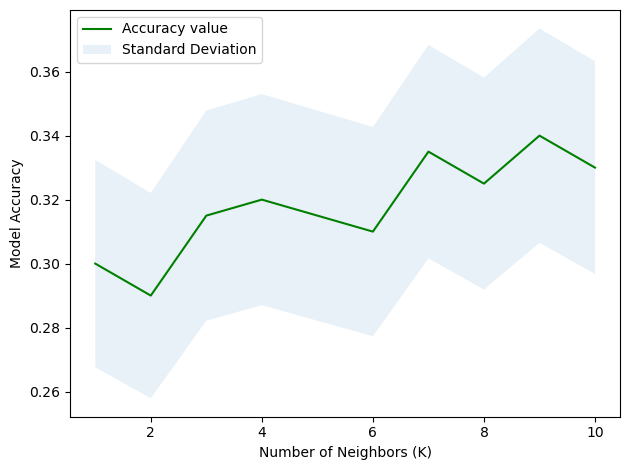

The best accuracy was with 0.34 with k = 9


In [40]:
plt.plot(range(1,Ks+1),acc,'g')
plt.fill_between(range(1,Ks+1),acc - 1 * std_acc,acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()
print( "The best accuracy was with", acc.max(), "with k =", acc.argmax()+1) 

From the accuracy plot, I can see that:

- 📈 The model accuracy is still **rising** as k increases  
- ⚠️ This suggests that an **even higher value of k** might improve performance further  

---

## 🔍 Implication

- The current range of k (1–9) may **not have reached the optimal value**  
- Testing **larger k values** could potentially yield a **more accurate and stable model**  
- This helps ensure I’m not **underestimating the ideal number of neighbors**  

---

## 💻 Next Step

I can extend the range of k values and continue evaluating performance to **find the best k** for this dataset 👇

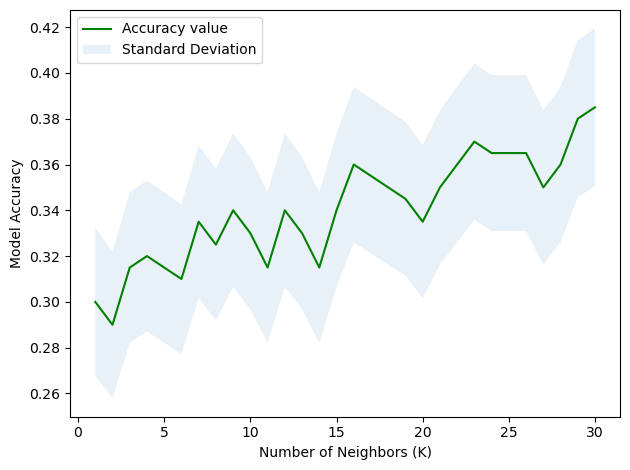

The best accuracy was with 0.385 with k = 30


In [43]:
# Run the training model for 30 values of k
Ks = 30
acc = np.zeros((Ks))
std_acc = np.zeros((Ks))
for n in range(1,Ks+1):
    #Train Model and Predict  
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat = knn_model_n.predict(X_test)
    acc[n-1] = accuracy_score(y_test, yhat)
    std_acc[n-1] = np.std(yhat==y_test)/np.sqrt(yhat.shape[0])
plt.plot(range(1,Ks+1),acc,'g')
plt.fill_between(range(1,Ks+1),acc - 1 * std_acc,acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()
print( "The best accuracy was with", acc.max(), "with k =", acc.argmax()+1) 

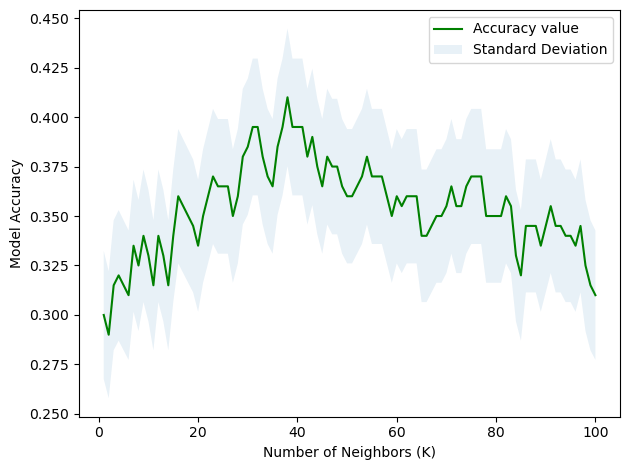

The best accuracy was with 0.41 with k = 38


In [44]:
# Run the training model for 100 values of k
Ks = 100
acc = np.zeros((Ks))
std_acc = np.zeros((Ks))
for n in range(1,Ks+1):                     
    #Train Model and Predict  
    knn_model_n = KNeighborsClassifier(n_neighbors = n).fit(X_train,y_train)
    yhat = knn_model_n.predict(X_test)
    acc[n-1] = accuracy_score(y_test, yhat)
    std_acc[n-1] = np.std(yhat==y_test)/np.sqrt(yhat.shape[0])
plt.plot(range(1,Ks+1),acc,'g')
plt.fill_between(range(1,Ks+1),acc - 1 * std_acc,acc + 1 * std_acc, alpha=0.10)
plt.legend(('Accuracy value', 'Standard Deviation'))
plt.ylabel('Model Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.tight_layout()
plt.show()
print( "The best accuracy was with", acc.max(), "with k =", acc.argmax()+1)